# Lib Installation

In [1]:
!pip install lightning pytorch-lightning torchvision tqdm python-dotenv PyYAML wilds timm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.0/846.0 kB 17.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 4.9 MB/s eta 0:00:00


In [2]:
# Cell 1: Install required libs (run in a cell)
!pip install lightning pytorch-lightning torchvision tqdm python-dotenv PyYAML wilds torchmetrics timm


# Config

In [3]:
config = {
    "algo": "FOND",

    # Only DomainNet
    "dataset": ["DomainNet"],

    # Test domain index (interpreted per dataset)
    "test_set_id": 0,  # e.g., 0=clipart for DomainNet if domain order is standard

    # Paths
    "data_dir": {
        "DomainNet": "/kaggle/input/domainnet/DomainNet"
    },

    "log_dir": "./logs",

    # Training settings
    "n_epochs": 5001,
    "checkpoint_freq": 4999,
    "holdout_fraction": 0.2,

    # Model checkpointing
    "model_checkpoint": {
        "metric": "val/oacc",
        "maximize": True
    },

    # Seeds
    "overall_seed": 1,
    "trial_id": 0,
    "hparam_id": 0,

    # System
    "num_workers": 4,

    # Dataset config
    "overlap": "high",  # Ignored by DomainNet (safe to keep)
    "num_classes": None,
    "num_domain_linked_classes": None,

    # AutoFOND specific (disabled for baseline)
    "auto_augment": False,
    "augment_search_epochs": 5,
    "augment_policy_size": 5,
    "augment_num_policies": 3,

    # Teacher paths
    "teacher_paths": {}
}


# Imports

In [4]:
import math
from typing import List, Any, Dict, Optional, Callable, Tuple
import argparse
import logging
import hashlib
import numpy as np
from collections import Counter
import collections
import time
from datetime import datetime
import lightning as L
from tqdm import tqdm
import csv
import json
from pathlib import Path
import os
import torch
import torchmetrics
import torchvision.datasets.folder
from PIL import Image, ImageFile
from torch.utils.data import ConcatDataset, Dataset, Subset, TensorDataset
from torchvision import transforms
from torchvision.datasets import MNIST, ImageFolder
from torchvision.transforms.functional import rotate
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models
from wilds.datasets.camelyon17_dataset import Camelyon17Dataset

# --- Added for ConvNeXt ---
import timm


/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

# SRC

## Domain Creation

In [7]:



def create_domains(
    num_classes: int, num_linked: int, num_train_domains: int
) -> List[List[int]]:
    """
    Determine and distribute domain-linked and domain-shared classes.
    Domain-linked classes will come from the same domain, i.e., idx=0.
    Domain-shared classes will exist in each of the remaining domains

    Args:
        num_classes: number of overall classes within all the domains
        num_linked: number of classes that are linked to an individual domain
        num_train_domains: number of different training domains
    """
    assert num_linked <= num_classes
    domain_shared = [i for i in range(num_linked, num_classes)]
    domain_linked = [i for i in range(num_linked)]
    logging.info(f"Domain-shared classes: {domain_shared}")
    logging.info(f"Domain-linked classes: {domain_linked}")
    # domains = [domain_shared.copy() for i in range(num_train_domains)]
    domains = [[] for i in range(num_train_domains)]

    # first domain is domain-linked only
    domains[0] = domain_linked
    # other domains contain domain-shared only
    domains[1:] = [domain_shared.copy() for i in range(1, num_train_domains)]

    logging.info(f"domains[0]: {domains[0]}")
    logging.info(f"domains[1:]: {domains[1:]}")

    return domains


def create_domains_1(
    num_classes: int, num_linked: int, num_domains: int
) -> List[List[int]]:
    """
    Args:
        num_classes: number of overall classes within all the domains
        num_linked: number of classes that are linked to an individual domain
        num_domains: number of different domains, including test domain
    """
    assert num_linked < num_classes
    domain_shared = [i for i in range(num_linked, num_classes)]
    print(f"Shared classes: {domain_shared}")
    num_train_domains = num_domains - 1
    domains = [domain_shared.copy() for i in range(num_train_domains)]

    for class_idx in range(num_linked):
        domain_idx = class_idx % num_train_domains
        domains[domain_idx].append(class_idx)
    return domains


def create_domains_2(
    num_classes: int, num_linked_ratio: float, num_domains: int
) -> List[List[int]]:
    """
    Args:
        num_classes: number of overall classes within all the domains
        num_linked_ratio: ratio of linked classes to the total number of classes
        num_domains: number of different domains, including test domain
    """
    num_linked = math.floor(num_linked_ratio * num_classes)
    return create_domains_1(num_classes, num_linked, num_domains)



# Testing
create_domains(num_classes=10, num_linked=5, num_train_domains=3)
# Testing domain linked only
create_domains(num_classes=10, num_linked=10, num_train_domains=3)

# Testing same classes with different overlap
domains = create_domains_1(num_classes=10, num_linked=3, num_domains=4)
print(domains)
domains = create_domains_1(num_classes=10, num_linked=5, num_domains=4)
print(domains)

# Testing different classes with same overlap percentage
domains = create_domains_2(num_classes=10, num_linked_ratio=0.2, num_domains=4)
print(domains)
domains = create_domains_2(num_classes=5, num_linked_ratio=0.2, num_domains=4)
print(domains)


Shared classes: [3, 4, 5, 6, 7, 8, 9]
[[3, 4, 5, 6, 7, 8, 9, 0], [3, 4, 5, 6, 7, 8, 9, 1], [3, 4, 5, 6, 7, 8, 9, 2]]
Shared classes: [5, 6, 7, 8, 9]
[[5, 6, 7, 8, 9, 0, 3], [5, 6, 7, 8, 9, 1, 4], [5, 6, 7, 8, 9, 2]]
Shared classes: [2, 3, 4, 5, 6, 7, 8, 9]
[[2, 3, 4, 5, 6, 7, 8, 9, 0], [2, 3, 4, 5, 6, 7, 8, 9, 1], [2, 3, 4, 5, 6, 7, 8, 9]]
Shared classes: [1, 2, 3, 4]
[[1, 2, 3, 4, 0], [1, 2, 3, 4], [1, 2, 3, 4]]


## Hparams

In [9]:
"""
Hyper-parameter registry
"""

def seed_hash(*args):
    """
    Derive an integer hash from all args, for use as a random seed.
    """
    args_str = str(args)
    return int(hashlib.md5(args_str.encode("utf-8")).hexdigest(), 16) % (2**31)


def _define_hparam(hparams, hparam_name, default_val, random_val_fn):
    hparams[hparam_name] = (hparams, hparam_name, default_val, random_val_fn)


def _hparams(algorithm, dataset, random_seed):
    """
    Global registry of hyperparams. Each entry is a (default, random) tuple.
    New algorithms / networks / etc. should add entries here.
    """
    SMALL_IMAGES = ["Debug28", "RotatedMNIST", "ColoredMNIST"]

    hparams = {}

    def _hparam(name, default_val, random_val_fn):
        """Define a hyperparameter. random_val_fn takes a RandomState and
        returns a random hyperparameter value."""
        assert name not in hparams
        random_state = np.random.RandomState(seed_hash(random_seed, name))
        hparams[name] = (default_val, random_val_fn(random_state))

    # Unconditional hparam definitions.
    _hparam("data_augmentation", True, lambda r: True)
    
    # Backbone options
    _hparam("resnet18", False, lambda r: False)  # Set False because we'll use ConvNeXt
    _hparam("use_convnext", True, lambda r: True)  # NEW: ConvNeXt flag
    _hparam("resnet_dropout", 0.0, lambda r: r.choice([0.0, 0.1, 0.5]))
    
    _hparam("class_balanced", False, lambda r: False)
    _hparam("nonlinear_classifier", False, lambda r: False)

    # Algorithm-specific hparam definitions
    if algorithm in ["FOND", "FOND_NC", "FOND_N", "NOC"]:
        _hparam("temperature", 0.07, lambda r: 0.07 * r.uniform(0.75, 1.25))
        _hparam("base_temperature", 0.07, lambda r: 0.07)
        _hparam("xdom_lmbd", 1, lambda r: 10 ** r.uniform(-1, 3))
        _hparam("error_lmbd", 1, lambda r: 10 ** r.uniform(-1, 3))
        _hparam("xda_alpha", 1, lambda r: 10 ** r.uniform(0, 1))
        _hparam("xda_beta", 1, lambda r: 10 ** r.uniform(0, 1))
    elif algorithm in [
        "FOND_Distillation_Separate_Projector",
        "FOND_Distillation_Teacher_Projector",
        "FOND_Distillation_Student_Projector",
    ]:
        _hparam("temperature", 0.07, lambda r: 0.07 * r.uniform(0.75, 1.25))
        _hparam("base_temperature", 0.07, lambda r: 0.07)
        _hparam("xdom_lmbd", 1, lambda r: 10 ** r.uniform(-1, 3))
        _hparam("error_lmbd", 1, lambda r: 10 ** r.uniform(-1, 3))
        _hparam("xda_alpha", 1, lambda r: 10 ** r.uniform(0, 1))
        _hparam("xda_beta", 1, lambda r: 10 ** r.uniform(0, 1))
        _hparam("distillation_temperature", 1, lambda r: r.uniform(1, 20))

    # Dataset-specific hyperparams
    if dataset in SMALL_IMAGES:
        _hparam("lr", 1e-3, lambda r: 10 ** r.uniform(-4.5, -2.5))
        _hparam("weight_decay", 0.0, lambda r: 0.0)
        _hparam("batch_size", 64, lambda r: int(2 ** r.uniform(3, 9)))
    else:
        _hparam("lr", 5e-5, lambda r: 10 ** r.uniform(-5, -3.5))
        _hparam("weight_decay", 0.0, lambda r: 10 ** r.uniform(-6, -2))
        if algorithm == "ARM":
            _hparam("batch_size", 8, lambda r: 8)
        elif dataset == "DomainNet":
            _hparam("batch_size", 32, lambda r: int(2 ** r.uniform(3, 5)))
        else:
            _hparam("batch_size", 32, lambda r: int(2 ** r.uniform(3, 5.5)))

    return hparams


def default_hparams(algorithm, dataset):
    return {a: b for a, (b, c) in _hparams(algorithm, dataset, 0).items()}


def random_hparams(algorithm, dataset, seed):
    return {a: c for a, (b, c) in _hparams(algorithm, dataset, seed).items()}


## Misc

In [10]:

class _SplitDataset(torch.utils.data.Dataset):
    """Used by split_dataset"""

    def __init__(self, underlying_dataset, keys):
        super(_SplitDataset, self).__init__()
        self.underlying_dataset = underlying_dataset
        self.keys = keys

    def __getitem__(self, key):
        return self.underlying_dataset[self.keys[key]]

    def __len__(self):
        return len(self.keys)


def split_dataset(dataset, n, seed=0):
    """
    Return a pair of datasets corresponding to a random split of the given
    dataset, with n datapoints in the first dataset and the rest in the last,
    using the given random seed
    """
    assert n <= len(dataset)
    keys = list(range(len(dataset)))
    np.random.RandomState(seed).shuffle(keys)
    keys_1 = keys[:n]
    keys_2 = keys[n:]
    return _SplitDataset(dataset, keys_1), _SplitDataset(dataset, keys_2)


def seed_hash(*args):
    """
    Derive an integer hash from all args, for use as a random seed.
    """
    args_str = str(args)
    return int(hashlib.md5(args_str.encode("utf-8")).hexdigest(), 16) % (2**31)


def make_weights_for_balanced_classes(dataset):
    counts = Counter()
    classes = []
    for _, y in dataset:
        y = int(y)
        counts[y] += 1
        classes.append(y)

    n_classes = len(counts)

    weight_per_class = {}
    for y in counts:
        weight_per_class[y] = 1 / (counts[y] * n_classes)

    weights = torch.zeros(len(dataset))
    for i, y in enumerate(classes):
        weights[i] = weight_per_class[int(y)]

    return weights
def compute_loss(network, loader, device):
    """
    Compute average loss for a given loader.
    Returns: average loss value
    """
    total_loss = 0.0
    num_batches = 0
    
    network.eval()
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            p = network.predict(x)
            
            # Compute loss
            loss = torch.nn.functional.cross_entropy(p, y, reduction='mean')
            total_loss += loss.item()
            num_batches += 1
    
    network.train()
    
    avg_loss = total_loss / num_batches if num_batches > 0 else 0.0
    return avg_loss

def accuracy(network, loader, weights, device, dataset):
    correct = 0
    total = 0
    weights_offset = 0
    overlapping_classes = dataset.overlapping_classes
    num_classes = dataset.num_classes
    
    f1_score = torchmetrics.F1Score(
        task="multiclass", num_classes=num_classes, average="macro"
    ).to(device)
    per_class_accuracy = torchmetrics.Accuracy(
        task="multiclass",
        num_classes=num_classes,
        average=None,
    ).to(device)
    accuracy = torchmetrics.Accuracy(
        task="multiclass",
        num_classes=num_classes,
        average="macro",
    ).to(device)
    recall = torchmetrics.Recall(
        task="multiclass",
        num_classes=num_classes,
        average="macro",
    ).to(device)
    precision = torchmetrics.Precision(
        task='multiclass',  # ✅ Fixed typo
        num_classes=num_classes,
        average='macro'
    ).to(device)
    conf_mat = torchmetrics.ConfusionMatrix(
        task="multiclass",
        num_classes=num_classes
    ).to(device)  # ✅ Added .to(device)
    
    network.eval()
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            p = network.predict(x)
            
            if weights is None:
                batch_weights = torch.ones(len(x))
            else:
                batch_weights = weights[weights_offset : weights_offset + len(x)]
                weights_offset += len(x)
            batch_weights = batch_weights.to(device)
            
            if p.size(1) == 1:
                correct += (
                    (p.gt(0).eq(y).float() * batch_weights.view(-1, 1)).sum().item()
                )
            else:
                correct += (p.argmax(1).eq(y).float() * batch_weights).sum().item()
            total += batch_weights.sum().item()
            
            # update metrics
            accuracy.update(p, y)
            recall.update(p, y)
            precision.update(p, y)
            f1_score.update(p, y)
            per_class_accuracy.update(p, y)
            conf_mat.update(p, y)
    
    network.train()
    compute_acc = accuracy.compute().item()
    compute_recall = recall.compute().item()
    compute_precision = precision.compute().item()  # ✅ Fixed typo
    compute_f1 = f1_score.compute().item()
    compute_per_class_acc = per_class_accuracy.compute().cpu().numpy()
    cm_compute = conf_mat.compute().cpu().numpy()  # ✅ Convert to numpy
    
    overlap_class_acc = []
    non_overlap_class_acc = []
    per_class_acc_dict = {}
    for i in range(num_classes):
        per_class_acc_dict[i] = float(compute_per_class_acc[i])
        if i in overlapping_classes:
            overlap_class_acc.append(compute_per_class_acc[i])
        else:
            non_overlap_class_acc.append(compute_per_class_acc[i])
    
    if len(non_overlap_class_acc) == 0:
        non_overlap_class_acc = -1
    else:
        non_overlap_class_acc = np.mean(non_overlap_class_acc)
    if len(overlap_class_acc) == 0:
        overlap_class_acc = -1
    else:
        overlap_class_acc = np.mean(overlap_class_acc)
    
    other_acc = correct / total
    
    return (
        float(compute_acc),
        float(compute_recall),
        float(compute_f1),
        float(compute_precision),      # ✅ Moved before oacc/nacc
        float(overlap_class_acc),
        float(non_overlap_class_acc),
        per_class_acc_dict,
        cm_compute
    )
class _InfiniteSampler(torch.utils.data.Sampler):
    """Wraps another Sampler to yield an infinite stream."""

    def __init__(self, sampler):
        self.sampler = sampler

    def __iter__(self):
        while True:
            for batch in self.sampler:
                yield batch


class InfiniteDataLoader:
    def __init__(self, dataset, weights, batch_size, num_workers):
        super().__init__()

        if weights is not None:
            sampler = torch.utils.data.WeightedRandomSampler(
                weights, replacement=True, num_samples=batch_size
            )
        else:
            sampler = torch.utils.data.RandomSampler(dataset, replacement=True)

        if weights == None:
            weights = torch.ones(len(dataset))

        batch_sampler = torch.utils.data.BatchSampler(
            sampler, batch_size=batch_size, drop_last=True
        )

        self._infinite_iterator = iter(
            torch.utils.data.DataLoader(
                dataset,
                num_workers=num_workers,
                batch_sampler=_InfiniteSampler(batch_sampler),
            )
        )

    def __iter__(self):
        while True:
            yield next(self._infinite_iterator)

    def __len__(self):
        raise ValueError


class FastDataLoader:
    """DataLoader wrapper with slightly improved speed by not respawning worker
    processes at every epoch."""

    def __init__(self, dataset, batch_size, num_workers):
        super().__init__()

        batch_sampler = torch.utils.data.BatchSampler(
            torch.utils.data.RandomSampler(dataset, replacement=False),
            batch_size=batch_size,
            drop_last=False,
        )

        self._infinite_iterator = iter(
            torch.utils.data.DataLoader(
                dataset,
                num_workers=num_workers,
                batch_sampler=_InfiniteSampler(batch_sampler),
            )
        )

        self._length = len(batch_sampler)

    def __iter__(self):
        for _ in range(len(self)):
            yield next(self._infinite_iterator)

    def __len__(self):
        return self._length


def config_logging():
    """
    Reusable code for formatting the logger
    """
    logging.basicConfig(
        format="%(asctime)s,%(msecs)03d %(levelname)-8s [%(filename)s:%(funcName)s:%(lineno)d] %(message)s",
        datefmt="%Y-%m-%d:%H:%M:%S",
        level=logging.INFO,
    )


## Simple Logger

In [11]:
"""
Simple CSV logger to replace W&B during development
Keeps the same interface for easy swap later
"""
class CSVLogger:
    """Lightweight logger that writes metrics to CSV"""
    
    def __init__(self, csv_path: str, root_dir:str=None):
        self.csv_path = Path(csv_path)
        self.csv_path.parent.mkdir(parents=True, exist_ok=True)
        self.fieldnames = None
        self.file = None
        self.writer = None
        self._init_csv()
        self.root = root_dir if root_dir is not None else csv_path.parent
    def _init_csv(self):
        """Initialize CSV file with headers"""
        self.file = open(self.csv_path, 'w', newline='')
        self.writer = None  # Will be created on first log
    def return_root(self):
        return self.root
    def log(self, metrics: Dict[str, Any], step: Optional[int] = None):
        """
        Log metrics to CSV
        
        Args:
            metrics: Dictionary of metric_name -> value
            step: Training step (optional, will be added if provided)
        """
        if step is not None:
            metrics = {"step": step, **metrics}
            
        # Flatten nested dictionaries (e.g., {"train/acc": 0.9})
        flat_metrics = {}
        for key, value in metrics.items():
            if isinstance(value, dict):
                for subkey, subvalue in value.items():
                    flat_metrics[f"{key}/{subkey}"] = subvalue
            else:
                flat_metrics[key] = value
        
        # Initialize writer with fieldnames on first call
        if self.writer is None:
            self.fieldnames = list(flat_metrics.keys())
            self.writer = csv.DictWriter(self.file, fieldnames=self.fieldnames)
            self.writer.writeheader()
            
        # Add new fields if they appear
        new_fields = set(flat_metrics.keys()) - set(self.fieldnames)
        if new_fields:
            self.fieldnames.extend(sorted(new_fields))
            # Rewrite file with new headers
            self.file.close()
            self._rewrite_with_new_fields(flat_metrics)
            return
            
        self.writer.writerow(flat_metrics)
        self.file.flush()  # Ensure immediate write
        
    def _rewrite_with_new_fields(self, new_row: Dict[str, Any]):
        """Rewrite CSV when new fields are discovered"""
        # Read existing rows
        with open(self.csv_path, 'r') as f:
            reader = csv.DictReader(f)
            existing_rows = list(reader)
        
        # Rewrite with updated fieldnames
        self.file = open(self.csv_path, 'w', newline='')
        self.writer = csv.DictWriter(self.file, fieldnames=self.fieldnames)
        self.writer.writeheader()
        for row in existing_rows:
            self.writer.writerow(row)
        self.writer.writerow(new_row)
        self.file.flush()
        
    def save_config(self, config: Dict[str, Any], path: Optional[str] = None):
        """Save experiment config as JSON"""
        if path is None:
            path = self.csv_path.parent / "config.json"
        with open(path, 'w') as f:
            json.dump(config, f, indent=2)
            
    def close(self):
        """Close CSV file"""
        if self.file:
            self.file.close()
            
    def __enter__(self):
        return self
        
    def __exit__(self, exc_type, exc_val, exc_tb):
        self.close()


class PrintLogger:
    """Even simpler logger that just prints to console"""
    
    def log(self, metrics: Dict[str, Any], step: Optional[int] = None):
        step_str = f"[Step {step}] " if step is not None else ""
        metric_str = ", ".join(f"{k}={v:.4f}" if isinstance(v, float) else f"{k}={v}" 
                               for k, v in metrics.items())
        print(f"{step_str}{metric_str}")
        
    def save_config(self, config: Dict[str, Any], path: Optional[str] = None):
        print(f"Config: {json.dumps(config, indent=2)}")
        
    def close(self):
        pass


# DADA

In [12]:
import os, json, random, logging
import numpy as np
import torch
import torch.nn as nn

from torchvision import transforms
from torch.utils.data import DataLoader

torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

# For reproducibility with ConvNeXt
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cuda


In [13]:
class DiffGaussianNoise(nn.Module):
    def __init__(self, std=0.05):
        super().__init__()
        self.std = std

    def forward(self, x):
        if not self.training:
            return x
        noise = torch.randn_like(x) * self.std
        return x + noise


class DiffColorJitter(nn.Module):
    def __init__(self, brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1):
        super().__init__()
        self.b = brightness
        self.c = contrast
        self.s = saturation
        self.h = hue

    def forward(self, img):
        if not self.training:
            return img

        if self.b > 0:
            img = img * (1 + torch.randn(1).item() * self.b)

        if self.c > 0:
            mean = img.mean(dim=[2,3], keepdim=True)
            img = (img - mean) * (1 + torch.randn(1).item() * self.c) + mean

        if self.s > 0:
            gray = img.mean(dim=1, keepdim=True)
            img = img + (img - gray) * (1 + torch.randn(1).item() * self.s)

        if self.h > 0:
            theta = torch.randn(1).item() * self.h
            u, w = torch.cos(torch.tensor(theta)), torch.sin(torch.tensor(theta))
            rot = torch.tensor([[u, -w, 0],[w, u, 0],[0, 0, 1]], device=img.device)
            img = torch.einsum('bchw,dc->bdhw', img, rot)

        return img


class DiffHSB(nn.Module):
    def __init__(self, hue=0.05, saturation=0.2, brightness=0.2):
        super().__init__()
        self.h = hue
        self.s = saturation
        self.b = brightness

    def forward(self, x):
        if not self.training:
            return x

        x = x * (1 + torch.randn(1).item() * self.h)
        x = torch.clamp(x, 0, 1)
        return x


class DiffAugment(nn.Module):
    def __init__(self):
        super().__init__()
        self.color = DiffColorJitter()
        self.hsb = DiffHSB()
        self.gauss = DiffGaussianNoise(0.03)

    def forward(self, x):
        x = self.color(x)
        x = self.hsb(x)
        x = self.gauss(x)
        return torch.clamp(x, 0, 1)


In [14]:
class AugmentedDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, diff_aug):
        self.base = base_dataset
        self.diff_aug = diff_aug

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x, y = self.base[idx]
        if isinstance(x, torch.Tensor):
            x = self.diff_aug(x.unsqueeze(0)).squeeze(0)
        return x, y



In [16]:
base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

diff_augment = DiffAugment().to(device)


In [17]:
def load_dataset(name, data_dir, domains, split, auto_augment):
    """
    Load DomainNet dataset and optionally apply differentiable augmentation to training set.
    """
    if name != "DomainNet":
        raise ValueError(f"Only DomainNet is supported in this notebook. Got: {name}")

    # Construct DomainNet path for the given domains
    domain_folders = [os.path.join(data_dir, d) for d in domains]
    all_datasets = []
    for d_folder in domain_folders:
        # ImageFolder expects: root/class_name/images
        all_datasets.append(torchvision.datasets.ImageFolder(
            root=d_folder,
            transform=base_transform
        ))
    dataset = torch.utils.data.ConcatDataset(all_datasets)

    # Apply DiffAugment ONLY for training and if auto_augment enabled
    if split.lower() == "train" and auto_augment:
        dataset = AugmentedDataset(dataset, diff_augment)

    return dataset


# Dataset

## Base

In [19]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
from typing import Callable, List, Optional, Dict
from torchvision.datasets import ImageFolder
from torchvision import transforms
import numpy as np
import os
import logging

def get_overlapping_classes(class_split: list, num_classes: int) -> list:
    overlap = np.zeros(num_classes)
    for data in class_split:
        np.add.at(overlap, data, 1)
    return list(np.where(overlap > 1)[0])


class DomainBedImageFolder(ImageFolder):
    """Custom ImageFolder to allow filtering classes"""

    def __init__(
        self,
        root: str,
        transform: Optional[Callable] = None,
        remove_classes: List[int] = [],
        allowed_classes: List[int] = [],
        is_test_env: Optional[bool] = None,
        env_name: Optional[str] = None,
    ):
        super().__init__(root, transform)
        old_samples = self.samples
        self.samples, self.targets = [], []
        self.is_test_env = is_test_env
        self.allowed_classes = allowed_classes
        self.remove_classes = remove_classes
        self.env_name = env_name

        for sample in old_samples:
            _, target = sample
            if target not in remove_classes:
                self.samples.append(sample)
                self.targets.append(target)

        self.imgs = self.samples
        self.classes = sorted(list(set(self.targets)))

    def __len__(self) -> int:
        return len(self.samples)

    def __str__(self):
        return (
            f"{self.env_name}: is_test_env={self.is_test_env}, "
            f"allowed_classes={self.allowed_classes}, classes={self.classes}, num_samples={len(self)}"
        )


class MultipleEnvironmentImageFolder:
    """DomainNet-only multi-domain dataset loader for ConvNeXt"""

    def __init__(
        self,
        root,
        test_envs,
        augment: bool,
        domain_class_filter: List[List[int]],
        num_classes=None,
    ):
        environments = sorted([f.name for f in os.scandir(root) if f.is_dir()])
        assert len(test_envs) == 1, "Only single test environment supported"

        self.idx_to_class = self.get_idx_to_class(os.path.join(root, environments[test_envs[0]]))
        self.num_classes = len(self.idx_to_class) if num_classes is None else num_classes
        self.overlapping_classes = get_overlapping_classes(domain_class_filter, self.num_classes)
        logging.info(f"Overlapping classes: {self.overlapping_classes}")

        num_filters = len(domain_class_filter)
        assert len(environments) - 1 == num_filters, f"Num filters ({num_filters}) must match domains-1 ({len(environments)-1})"
        shift_filter = list(range(num_filters)) + list(range(num_filters))
        shift_filter = shift_filter[test_envs[0]: test_envs[0] + num_filters]

        # ConvNeXt-ready transforms
        transform = transforms.Compose([
            transforms.Resize((224,224)),
            transforms.ToTensor(),
            transforms.Lambda(lambda x: x.repeat(3,1,1) if x.shape[0]==1 else x),
            transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
        ])
        augment_transform = transforms.Compose([
            transforms.RandomResizedCrop(224, scale=(0.7,1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(0.3,0.3,0.3,0.3),
            transforms.RandomGrayscale(),
            transforms.ToTensor(),
            transforms.Lambda(lambda x: x.repeat(3,1,1) if x.shape[0]==1 else x),
            transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
        ])

        self.datasets = []
        for i, env_name in enumerate(environments):
            path = os.path.join(root, env_name)
            env_transform = augment_transform if augment and i not in test_envs else transform
            all_classes = set(self.idx_to_class.keys())

            if i not in test_envs:
                filt = domain_class_filter[shift_filter.pop()]
                if filt == []:
                    continue
                remove_classes = list(all_classes - set(filt))
                env_dataset = DomainBedImageFolder(
                    path, transform=env_transform, remove_classes=remove_classes,
                    allowed_classes=filt, is_test_env=False, env_name=env_name
                )
            else:
                remove_classes = list(range(self.num_classes, len(all_classes)))
                env_dataset = DomainBedImageFolder(
                    path, transform=env_transform, remove_classes=remove_classes,
                    allowed_classes=list(range(self.num_classes)), is_test_env=True, env_name=env_name
                )
                assert self.num_classes == len(env_dataset.classes)

            logging.info(f"Created domain -> {env_dataset}")
            self.datasets.append(env_dataset)

        self.input_shape = (3,224,224)

    def get_idx_to_class(self, data_dir: str) -> Dict[int,str]:
        dataset = ImageFolder(data_dir)
        return {v:k for k,v in dataset.class_to_idx.items()}

    # ✅ Make iterable so fit_simple works
    def __iter__(self):
        return iter(self.datasets)

    def __len__(self):
        return len(self.datasets)


# Domain Net

In [20]:
class DomainNet(MultipleEnvironmentImageFolder):
    CHECKPOINT_FREQ = 500
    ENVIRONMENTS = sorted(["clipart", "infograph", "painting", "quickdraw", "real", "sketch"])
    NUM_CLASSES = 345  # total classes in DomainNet; adjust if using a subset
    OVERLAP_CONFIG = {
        "0": [list(range(0, 58)), list(range(58, 116)), list(range(116, 174)),
              list(range(174, 232)), list(range(232, 290)), list(range(290, 345))],
        "low": [list(range(0, 100)), list(range(80, 180)), list(range(160, 260)),
                list(range(240, 340)), list(range(20, 120)), list(range(300, 345))],
        "high": [list(range(0, 200)), list(range(50, 250)), list(range(100, 300)),
                 list(range(150, 345)), list(range(0, 145)), list(range(200, 345))],
        "100": [list(range(345)) for _ in range(6)],
        "low_linked_only": [list(range(0, 50)), list(range(60, 110)), [], [], list(range(200, 250)), []],
        "high_linked_only": [list(range(0, 150)), [], list(range(200, 300)), [], [], list(range(300, 345))]
    }

    def __init__(self, root: str, test_envs: list, hparams: dict, overlap_type: str,
                 overlap_seed=None, num_classes=None, num_domain_linked_classes=None):

        self.dir = root
        self._num_classes = DomainNet.NUM_CLASSES if num_classes is None else num_classes

        if overlap_seed is not None:
            np.random.seed(overlap_seed)

        # Remove the test environment from overlap config
        full_overlap = DomainNet.OVERLAP_CONFIG[overlap_type]
        source_overlap = [lst for i, lst in enumerate(full_overlap) if i not in test_envs]

        super().__init__(
            root=self.dir,
            test_envs=test_envs,
            augment=hparams.get("data_augmentation", True),
            domain_class_filter=source_overlap,
            num_classes=self._num_classes
        )


## INIT

In [21]:
DATASETS = {
    "DomainNet": DomainNet
}


# Networks

# ConvoneXT

## Base


In [22]:
import torchvision
from torchvision.models import (
    resnet18, resnet50, ResNet18_Weights, ResNet50_Weights,
    convnext_tiny, ConvNeXt_Tiny_Weights
)
import torch.nn.functional as F

class Identity(nn.Module):
    """An identity layer"""
    def __init__(self):
        super().__init__()
    def forward(self, x):
        return x


class ResNet(nn.Module):
    """ResNet backbone with softmax chopped off and batchnorm frozen"""
    def __init__(self, input_shape, hparams):
        super().__init__()
        resnet18_flag = hparams.get("resnet18", True)
        if resnet18_flag:
            pretrain_weight = os.path.expanduser("~/scratch/saved/resnet18-f37072fd.pth")
            if os.path.exists(pretrain_weight):
                self.network = resnet18()
                self.network.load_state_dict(torch.load(pretrain_weight))
            else:
                self.network = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
            self.n_outputs = 512
        else:
            pretrain_weight = os.path.expanduser("~/scratch/saved/resnet50-11ad3fa6.pth")
            if os.path.exists(pretrain_weight):
                self.network = resnet50()
                self.network.load_state_dict(torch.load(pretrain_weight))
            else:
                self.network = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
            self.n_outputs = 2048

        # Adapt input channels
        nc = input_shape[0]
        if nc != 3:
            tmp = self.network.conv1.weight.data.clone()
            self.network.conv1 = nn.Conv2d(nc, 64, 7, 2, 3, bias=False)
            for i in range(nc):
                self.network.conv1.weight.data[:, i, :, :] = tmp[:, i % 3, :, :]

        # Remove classification head
        self.network.fc = Identity()
        self.freeze_bn()
        self.dropout = nn.Dropout(hparams.get("resnet_dropout", 0.0))

    def forward(self, x):
        return self.dropout(self.network(x))

    def train(self, mode=True):
        super().train(mode)
        self.freeze_bn()

    def freeze_bn(self):
        for m in self.network.modules():
            if isinstance(m, nn.BatchNorm2d):
                m.eval()


class ConvNeXt(nn.Module):
    """ConvNeXt backbone with softmax removed"""
    def __init__(self, input_shape, variant="tiny", pretrained=True, hparams=None):
        super().__init__()
        self.hparams = hparams
        if variant == "tiny":
            self.network = convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1 if pretrained else None)
            self.n_outputs = 768
        else:
            raise NotImplementedError(f"ConvNeXt variant {variant} not implemented")

        # Adapt input channels
        nc = input_shape[0]
        if nc != 3:
            tmp = self.network.features[0][0].weight.data.clone()
            self.network.features[0][0] = nn.Conv2d(nc, 96, kernel_size=4, stride=4)
            for i in range(nc):
                self.network.features[0][0].weight.data[:, i, :, :] = tmp[:, i % 3, :, :]

        # Remove classifier head
        self.network.classifier = Identity()
        self.dropout = nn.Dropout(hparams.get("resnet_dropout", 0.0) if hparams else 0.0)

    def forward(self, x):
        return self.dropout(self.network(x))


def Featurizer(input_shape, hparams):
    """Auto-select featurizer based on input shape or backbone choice"""
    if input_shape[1:3] == (224, 224):
        if hparams.get("backbone", "resnet") == "convnext":
            return ConvNeXt(input_shape, variant="tiny", pretrained=True, hparams=hparams)
        else:
            return ResNet(input_shape, hparams)
    else:
        raise NotImplementedError("Input shape not supported")


def Classifier(in_features, out_features, is_nonlinear=False):
    if is_nonlinear:
        return nn.Sequential(
            nn.Linear(in_features, in_features // 2),
            nn.ReLU(),
            nn.Linear(in_features // 2, in_features // 4),
            nn.ReLU(),
            nn.Linear(in_features // 4, out_features),
        )
    else:
        return nn.Linear(in_features, out_features)


class Algorithm(nn.Module):
    """Base class for domain generalization algorithms"""
    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super().__init__()
        self.hparams = hparams

    def update(self, minibatches, unlabeled=None):
        raise NotImplementedError

    def predict(self, x):
        raise NotImplementedError


class ERM(Algorithm):
    """Empirical Risk Minimization (ERM)"""
    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super().__init__(input_shape, num_classes, num_domains, hparams)
        self.featurizer = Featurizer(input_shape, self.hparams)
        self.classifier = Classifier(
            self.featurizer.n_outputs, num_classes, self.hparams.get("nonlinear_classifier", False)
        )
        self.network = nn.Sequential(self.featurizer, self.classifier)
        self.optimizer = torch.optim.Adam(
            self.network.parameters(),
            lr=self.hparams.get("lr", 1e-3),
            weight_decay=self.hparams.get("weight_decay", 0.0),
        )

    def update(self, minibatches, unlabeled=None):
        all_x = torch.cat([x for x, y in minibatches])
        all_y = torch.cat([y for x, y in minibatches])
        loss = F.cross_entropy(self.predict(all_x), all_y)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        return {"loss": loss.item()}

    def predict(self, x):
        return self.network(x)


## Fond

In [23]:
class AbstractXDom(ERM):
    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super().__init__(input_shape, num_classes, num_domains, hparams)

        self.domain_relations = hparams.get("domain_relations", None)
        self.temperature = hparams["temperature"]
        self.base_temperature = hparams["base_temperature"]

        # <-- UPDATED: Use featurizer output dynamically for any backbone -->
        encoder_output = self.featurizer.n_outputs
        self.projector = nn.Sequential(
            nn.Linear(encoder_output, encoder_output),
            nn.ReLU(),
            nn.Linear(encoder_output, 256),
        )

        # Xavier init for Linear and Conv2d
        def weight_init(m):
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

        self.projector.apply(weight_init)

        # optimizer includes featurizer, classifier, projector
        self.optimizer = torch.optim.Adam(
            list(self.featurizer.parameters()) +
            list(self.classifier.parameters()) +
            list(self.projector.parameters()),
            lr=hparams["lr"],
            weight_decay=hparams["weight_decay"],
        )

    def get_masks(self, Y, D):
        """Generate masks relating samples and their domains/classes"""
        self_mask = (~torch.eye(Y.shape[0], dtype=torch.bool)).to(Y.device)
        same_Y_mask = Y.view(-1, 1) == Y.view(-1, 1).T
        same_D_mask = D.view(-1, 1) == D.view(-1, 1).T
        return {
            "self_mask": self_mask,
            "same_class_mask": same_Y_mask,
            "same_class_exclude_self_mask": same_Y_mask * self_mask,
            "same_domain_mask": same_D_mask,
            "diff_domain_mask": ~same_D_mask,
            "diff_domain_same_class_mask": same_Y_mask * ~same_D_mask,
            "same_domain_diff_class_mask": ~same_Y_mask * same_D_mask,
            "same_domain_same_class_mask": same_Y_mask * same_D_mask,
        }

    def supcon_loss(self, projections, positive_mask, negative_mask, alpha, beta, epsilon=1e-6):
        """FOND FBA Loss with custom masks"""
        mean_positives_per_sample = torch.count_nonzero(positive_mask) / projections.shape[0]
        num_zero_positives = projections.shape[0] - torch.count_nonzero(positive_mask.sum(1))

        proj_dot = torch.matmul(projections, projections.T) / self.temperature
        logits_max, _ = torch.max(proj_dot, dim=1, keepdim=True)
        logits = proj_dot - logits_max.detach()

        exp_logits = torch.exp(logits) * negative_mask * beta
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True) + epsilon)

        mean_log_prob_pos = (positive_mask * alpha * log_prob).sum(1) / (positive_mask.sum(1) + epsilon)
        loss = -(self.temperature / self.base_temperature) * mean_log_prob_pos
        return loss.mean(), mean_positives_per_sample, num_zero_positives

    def preprocess(self, minibatches):
        num_domains = len(minibatches)
        features = [self.featurizer(xi) for xi, _ in minibatches]
        projections = [F.normalize(self.projector(fi)) for fi in features]
        classifs = [self.classifier(fi) for fi in features]
        targets = [yi for _, yi in minibatches]

        domains = [torch.zeros(len(x), dtype=torch.uint8, device=x.device) + i
                   for i, x in enumerate(targets)]

        if self.domain_relations is not None:
            for old, new in self.domain_relations.items():
                for d in domains:
                    d[d == old] = new

        return {"features": features, "projections": projections, "classifs": classifs,
                "targets": targets, "domains": domains, "num_domains": num_domains}

    def update(self, minibatches, unlabeled=None):
        raise NotImplementedError()


class FONDBase(AbstractXDom):
    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super().__init__(input_shape, num_classes, num_domains, hparams)
        self.xdom_lmbd = hparams["xdom_lmbd"]
        self.error_lmbd = hparams["error_lmbd"]
        self.xda_alpha = hparams["xda_alpha"]
        self.xda_beta = hparams["xda_beta"]
        self.C_oc = hparams["C_oc"]

        oc_weight = torch.zeros(num_classes, dtype=torch.bool)
        oc_weight[self.C_oc] = True
        self.oc_weight = oc_weight.float()
        self.noc_weight = (~oc_weight).float()

    def update(self, minibatches, unlabeled=None):
        values = self.preprocess(minibatches)
        domains = torch.cat(values["domains"])
        targets = torch.cat(values["targets"])
        classifs = torch.cat(values["classifs"])
        projections = torch.cat(values["projections"])

        masks = self.get_masks(Y=targets, D=domains)
        alpha = (~masks["diff_domain_same_class_mask"] + masks["diff_domain_same_class_mask"] * self.xda_alpha)
        beta = (~masks["same_domain_diff_class_mask"] + masks["same_domain_diff_class_mask"] * self.xda_beta)

        xdom_loss, mean_p, zero_p = self.supcon_loss(
            projections,
            positive_mask=masks["same_class_mask"] * masks["self_mask"],
            negative_mask=masks["self_mask"],
            alpha=alpha,
            beta=beta,
        )

        oc_class_loss = F.cross_entropy(classifs, targets, weight=self.oc_weight.to(targets.device))
        noc_class_loss = F.cross_entropy(classifs, targets, weight=self.noc_weight.to(targets.device))
        error_loss = oc_class_loss - noc_class_loss
        if torch.isnan(error_loss):
            error_loss = torch.tensor(0., device=targets.device)

        class_loss = F.cross_entropy(classifs, targets)
        loss = class_loss + self.xdom_lmbd * xdom_loss + self.error_lmbd * torch.abs(error_loss)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return {"loss": loss.item(), "class_loss": class_loss.item(),
                "xdom_loss": xdom_loss.item(), "error_loss": error_loss.item(),
                "mean_p": mean_p.item(), "zero_p": zero_p.item()}


class FOND(FONDBase):
    pass


class FOND_NC(FONDBase):
    def update(self, minibatches, unlabeled=None):
        values = self.preprocess(minibatches)
        domains = torch.cat(values["domains"])
        targets = torch.cat(values["targets"])
        classifs = torch.cat(values["classifs"])
        projections = torch.cat(values["projections"])

        masks = self.get_masks(Y=targets, D=domains)
        alpha = (~masks["diff_domain_same_class_mask"] + masks["diff_domain_same_class_mask"] * self.xda_alpha)
        beta = (~masks["same_domain_diff_class_mask"] + masks["same_domain_diff_class_mask"] * self.xda_beta)

        xdom_loss, mean_p, zero_p = self.supcon_loss(
            projections,
            positive_mask=masks["same_class_mask"] * masks["self_mask"],
            negative_mask=masks["self_mask"],
            alpha=alpha,
            beta=beta,
        )

        oc_class_loss = F.cross_entropy(classifs, targets, weight=self.oc_weight.to(targets.device))
        noc_class_loss = F.cross_entropy(classifs, targets, weight=self.noc_weight.to(targets.device))
        error_loss = oc_class_loss - noc_class_loss
        if torch.isnan(error_loss):
            error_loss = torch.tensor(0., device=targets.device)

        class_loss = F.cross_entropy(classifs, targets)
        if torch.isnan(noc_class_loss):
            noc_class_loss = torch.tensor(0., device=targets.device)

        loss = class_loss + self.xdom_lmbd * xdom_loss + self.error_lmbd * noc_class_loss
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return {"loss": loss.item(), "class_loss": class_loss.item(),
                "xdom_loss": xdom_loss.item(), "error_loss": error_loss.item(),
                "noc_class_loss": noc_class_loss.item(),
                "mean_p": mean_p.item(), "zero_p": zero_p.item()}


class FOND_N(FONDBase):
    def update(self, minibatches, unlabeled=None):
        values = self.preprocess(minibatches)
        domains = torch.cat(values["domains"])
        targets = torch.cat(values["targets"])
        classifs = torch.cat(values["classifs"])
        projections = torch.cat(values["projections"])

        masks = self.get_masks(Y=targets, D=domains)
        alpha = (~masks["diff_domain_same_class_mask"] + masks["diff_domain_same_class_mask"] * self.xda_alpha)
        beta = (~masks["same_domain_diff_class_mask"] + masks["same_domain_diff_class_mask"] * self.xda_beta)

        xdom_loss, mean_p, zero_p = self.supcon_loss(
            projections,
            positive_mask=masks["same_class_mask"] * masks["self_mask"],
            negative_mask=masks["self_mask"],
            alpha=alpha,
            beta=beta,
        )

        oc_class_loss = F.cross_entropy(classifs, targets, weight=self.oc_weight.to(targets.device))
        noc_class_loss = F.cross_entropy(classifs, targets, weight=self.noc_weight.to(targets.device))
        error_loss = oc_class_loss - noc_class_loss
        if torch.isnan(error_loss):
            error_loss = torch.tensor(0., device=targets.device)

        class_loss = F.cross_entropy(classifs, targets)
        if torch.isnan(noc_class_loss):
            noc_class_loss = torch.tensor(0., device=targets.device)

        loss = self.xdom_lmbd * xdom_loss + noc_class_loss
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return {"loss": loss.item(), "class_loss": class_loss.item(),
                "xdom_loss": xdom_loss.item(), "error_loss": error_loss.item(),
                "noc_class_loss": noc_class_loss.item(),
                "mean_p": mean_p.item(), "zero_p": zero_p.item()}


## Init

In [24]:


ALGORITHMS = {
    "ERM": ERM,
    "FOND": FOND,
    # "FOND_NC": "FOND_NC",
    # "FOND_N": "FOND_N",
    # "FOND_Distillation_Separate_Projector": "FOND_Distillation_Separate_Projector",
    # "FOND_Distillation_Teacher_Projector": "FOND_Distillation_Teacher_Projector",
    # "FOND_Distillation_Student_Projector": "FOND_Distillation_Student_Projector",
}


# Train

## Fit Simple

In [25]:
def fit_simple(
    exp_dir: str,
    logger,  # CSVLogger or PrintLogger
    seed: int,
    trial_seed: int,
    hparams_seed: int,
    algorithm_name: str,
    dataset_name: str,
    data_dir: str,
    num_workers: int,
    test_envs: list,
    overlap_type: str,
    holdout_fraction: float = 0.2,
    n_steps: int = 5001,  
    checkpoint_freq: int = 4999,  
    model_checkpoint: Optional[Dict] = None,
    teacher_paths: Optional[Dict] = None,
    num_domain_linked_classes: Optional[int] = None,
    num_classes: Optional[int] = None,
    auto_augment: bool = False,
    augment_search_epochs: int = 10,
):
    # seed everything
    L.seed_everything(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # get device
    if torch.cuda.is_available():
        device = "cuda"
    else:
        device = "cpu"
    
    # Setup hyper parameters
    if hparams_seed == 0:
        hparams = default_hparams(algorithm_name, dataset_name)
    else:
        hparams = random_hparams(
            algorithm_name, dataset_name, seed_hash(hparams_seed, trial_seed)
        )
    logging.info(f"hparams: {hparams}")
   
    # Get dataset
    dataset = DATASETS[dataset_name](
        root=data_dir,
        test_envs=test_envs,
        hparams=hparams,
        overlap_type=overlap_type,
        num_classes=num_classes,
        num_domain_linked_classes=num_domain_linked_classes,
    )
    
    # get overlapping classes
    hparams["C_oc"] = dataset.overlapping_classes
    logging.info(f"Loaded {dataset_name}")
    
    # Split each env into an 'in-split' and an 'out-split'
    in_splits = []
    out_splits = []
    relative_test_env = None
    log_dir = logger.return_root()
    
    for env_i, env in enumerate(dataset):
        out, in_ = split_dataset(
            env, int(len(env) * holdout_fraction), seed_hash(trial_seed, env_i)
        )
        
        if hparams["class_balanced"]:
            in_weights = make_weights_for_balanced_classes(in_)
            out_weights = make_weights_for_balanced_classes(out)
        else:
            in_weights, out_weights = None, None
        
        in_splits.append((in_, in_weights))
        out_splits.append((out, out_weights))
        
        # determine the relative test env id
        if env.is_test_env:
            relative_test_env = env_i
    
    assert relative_test_env is not None, "No testing domains"
    logging.info(f"test_envs={test_envs}, relative_test_env={relative_test_env}")
    
    # Setup data loaders
    train_loaders = [
        InfiniteDataLoader(
            dataset=env,
            weights=env_weights,
            batch_size=hparams["batch_size"],
            num_workers=num_workers,
        )
        for i, (env, env_weights) in enumerate(in_splits)
        if i != relative_test_env
    ]
    
    eval_loaders = [
        FastDataLoader(
            dataset=env,
            batch_size=hparams["batch_size"],
            num_workers=num_workers,
        )
        for env, _ in (in_splits + out_splits)
    ]
    
    eval_weights = [None for _, weights in (in_splits + out_splits)]
    
    eval_loader_names = ["env{}_in".format(i) for i in range(len(in_splits))]
    eval_loader_names += ["env{}_out".format(i) for i in range(len(out_splits))]
    logging.info(f"Created data loaders:  {eval_loader_names}")
    
    train_minibatches_iterator = zip(*train_loaders)
    steps_per_epoch = min([len(env) / hparams["batch_size"] for env, _ in in_splits])
    
    # Setup the algorithm
    if "distillation" in algorithm_name.lower():
        assert len(test_envs) == 1
        teacher_path = teacher_paths[dataset_name][str(test_envs[0])]
        teacher_algorithm = torch.load(teacher_path, map_location=device)
        
        algorithm = ALGORITHMS[algorithm_name](
            input_shape=dataset.input_shape,
            num_classes=dataset.num_classes,
            num_domains=len(dataset) - len(test_envs),
            hparams=hparams,
            teacher=teacher_algorithm,
        )
    else:
        algorithm = ALGORITHMS[algorithm_name](
            input_shape=dataset.input_shape,
            num_classes=dataset.num_classes,
            num_domains=len(dataset) - len(test_envs),
            hparams=hparams,
        )
    
    algorithm.to(device)
    logging.info(f"Algorithm {algorithm_name} setup")
    
    # Calculate model statistics
    total_params = sum(p.numel() for p in algorithm.parameters())
    trainable_params = sum(p.numel() for p in algorithm.parameters() if p.requires_grad)
    
    # Calculate model size in MB
    param_size = sum(p.nelement() * p.element_size() for p in algorithm.parameters())
    buffer_size = sum(b.nelement() * b.element_size() for b in algorithm.buffers())
    model_size_mb = (param_size + buffer_size) / (1024 ** 2)
    
    logging.info(f"Total parameters: {total_params:,}")
    logging.info(f"Trainable parameters: {trainable_params:,}")
    logging.info(f"Model size: {model_size_mb:.2f} MB")
    
    # Save model stats
    model_stats = {
        "total_params": total_params,
        "trainable_params": trainable_params,
        "model_size_mb": model_size_mb,
        "dataset": dataset_name,
        "algorithm": algorithm_name,
    }
    
    import json
    with open(os.path.join(log_dir, "model_statistics.json"), "w") as f:
        json.dump(model_stats, f, indent=4)
    
    # Training loop
    logging.info(f"Begining training loop, with {steps_per_epoch} steps per epoch")
    checkpoint_vals = collections.defaultdict(lambda: [])
    
    # track the model checkpoint value
    best_model_checkpoint_value = None
    best_model_checkpoint_path = ""
    
    # get checkpoint parameters
    checkpoint_metric = model_checkpoint["metric"].split("/")
    stage, metric = checkpoint_metric[0], checkpoint_metric[1]
    print(f"Model checkpoint frequency: {checkpoint_freq}")
    
    # Initialize epoch-based tracking
    epoch_history = {
        "train": {"loss": [], "acc": [], "precision": [], "recall": [], "f1": []},
        "val": {"loss": [], "acc": [], "precision": [], "recall": [], "f1": []},
        "test": {"loss": [], "acc": [], "precision": [], "recall": [], "f1": []},
        "epochs": [],
        "epoch_times": [],
    }
    
    # Track training time
    training_start_time = time.time()
    epoch_start_time = time.time()
    current_epoch = 0
    steps_in_current_epoch = 0
    
    for step in tqdm(list(range(n_steps))):
        step_start_time = time.time()
        
        # Get batches
        minibatches_device = [
            (x.to(device), y.to(device)) for x, y in next(train_minibatches_iterator)
        ]
        
        # Perform an update
        step_vals = algorithm.update(minibatches_device, None)
        for key, val in step_vals.items():
            checkpoint_vals[key].append(val)
        
        # Track epochs
        steps_in_current_epoch += 1
        
        # Check if we've completed an epoch
        if steps_in_current_epoch >= steps_per_epoch:
            epoch_time = time.time() - epoch_start_time
            epoch_history["epoch_times"].append(epoch_time)
            current_epoch += 1
            steps_in_current_epoch = 0
            epoch_start_time = time.time()
        
        # log
        if (step % checkpoint_freq == 0) or (step == n_steps - 1):
            results_dict = {
                key: {
                    _key: []
                    for _key in ["acc", "f1", "nacc", "oacc", "recall", "precision", "cm", "loss"]
                    + [f"acc-{i}" for i in range(dataset.num_classes)]
                }
                for key in ["train", "val", "test", "other"]
            }
            
            # Calculate training value averages
            for key, val in checkpoint_vals.items():
                if np.isnan(np.mean(val)):
                    raise Exception(f"{key}: {np.mean(val)}")
                # Store the MEAN of training values, not the entire list
                results_dict["train"][str(key)] = [np.mean(val)]
            
            # Evaluation
            for name, loader, weights in zip(
                eval_loader_names,
                eval_loaders,
                eval_weights,
            ):
                # Compute metrics using existing accuracy function
                (acc, recall, f1, precision, oacc, nacc, per_class_acc, cm) = accuracy(
                    algorithm, loader, weights, device, dataset
                )
                
                # Compute loss separately
                loss = compute_loss(algorithm, loader, device)
                
                # env{domain_idx}_{rest_of_string} is how name is formatted
                domain_idx = int(name[3])
                
                loader_type = ""
                if domain_idx == relative_test_env:
                    if "in" in name:  # Note 'in' is the 80%
                        loader_type = "test"
                    else:
                        loader_type = "other"
                elif "out" in name:  # Note 'out' is the 20%
                    loader_type = "val"
                else:
                    loader_type = "train"
                
                # update results
                results_dict[loader_type]["acc"].append(float(acc))
                results_dict[loader_type]["recall"].append(float(recall))
                results_dict[loader_type]["f1"].append(float(f1))
                results_dict[loader_type]["precision"].append(float(precision))
                results_dict[loader_type]["nacc"].append(float(nacc))
                results_dict[loader_type]["oacc"].append(float(oacc))
                results_dict[loader_type]["cm"].append(cm)
                results_dict[loader_type]["loss"].append(float(loss))
                
                for class_id, class_acc in per_class_acc.items():
                    results_dict[loader_type]["acc-" + str(class_id)].append(class_acc)
            
            # Store epoch-level metrics
            current_epoch_num = step / steps_per_epoch
            epoch_history["epochs"].append(current_epoch_num)
            
            for split in ["train", "val", "test"]:
                if results_dict[split]["acc"]:
                    epoch_history[split]["acc"].append(np.mean(results_dict[split]["acc"]))
                    epoch_history[split]["precision"].append(np.mean(results_dict[split]["precision"]))
                    epoch_history[split]["recall"].append(np.mean(results_dict[split]["recall"]))
                    epoch_history[split]["f1"].append(np.mean(results_dict[split]["f1"]))
                    epoch_history[split]["loss"].append(np.mean(results_dict[split]["loss"]))
            
            # log metrics - using tqdm.write to avoid breaking progress bar
            tqdm.write(f"\n=== Step {step} (Epoch {current_epoch_num:.2f}) ===")
            tqdm.write(f"step_time: {time.time() - step_start_time:.4f}s")
            
            for stage in ["train", "val", "test", "other"]:
                if results_dict[stage]["acc"]:
                    tqdm.write(f"{stage.upper()}:")
                    tqdm.write(f"  loss: {np.mean(results_dict[stage]['loss']):.4f}")
                    tqdm.write(f"  acc: {np.mean(results_dict[stage]['acc']):.4f}")
                    tqdm.write(f"  precision: {np.mean(results_dict[stage]['precision']):.4f}")
                    tqdm.write(f"  recall: {np.mean(results_dict[stage]['recall']):.4f}")
                    tqdm.write(f"  f1: {np.mean(results_dict[stage]['f1']):.4f}")
                    tqdm.write(f"  oacc: {np.mean(results_dict[stage]['oacc']):.4f}")
                    tqdm.write(f"  nacc: {np.mean(results_dict[stage]['nacc']):.4f}")
            
            logger.log(results_dict, step)
            
            # Save model checkpoint
            if model_checkpoint is not None:
                # get checkpoint parameters
                checkpoint_metric = model_checkpoint["metric"].split("/")
                maximize = model_checkpoint["maximize"]
                stage, metric = checkpoint_metric[0], checkpoint_metric[1]
                
                # get current value
                current_model_checkpoint_value = np.nanmean(results_dict[stage][metric])
                ckpt_path = os.path.join(log_dir, f"{id}_model_step{step}.ckpt")
                
                if best_model_checkpoint_value == None:
                    best_model_checkpoint_value = current_model_checkpoint_value
                    best_model_checkpoint_path = ckpt_path
                    torch.save(algorithm, ckpt_path)
                elif (
                    best_model_checkpoint_value < current_model_checkpoint_value
                ) and maximize:
                    torch.save(algorithm, ckpt_path)
                    # remove previous checkpoint
                    os.remove(best_model_checkpoint_path)
                    # update
                    logging.info(
                        "Updated {} from {} to {}".format(
                            model_checkpoint["metric"],
                            best_model_checkpoint_value,
                            current_model_checkpoint_value,
                        )
                    )
                    best_model_checkpoint_value = current_model_checkpoint_value
                    best_model_checkpoint_path = ckpt_path
                elif (
                    best_model_checkpoint_value > current_model_checkpoint_value
                ) and not maximize:
                    torch.save(algorithm, ckpt_path)
                    # remove previous checkpoint
                    os.remove(best_model_checkpoint_path)
                    # update
                    logging.info(
                        "Updated {} from {} to {}".format(
                            model_checkpoint["metric"],
                            best_model_checkpoint_value,
                            current_model_checkpoint_value,
                        )
                    )
                    best_model_checkpoint_value = current_model_checkpoint_value
                    best_model_checkpoint_path = ckpt_path
            
            checkpoint_vals = collections.defaultdict(lambda: [])
    
    # TRAINING COMPLETE - NOW PRINT EVERYTHING
    
    # Calculate total training time
    total_training_time = time.time() - training_start_time
    avg_epoch_time = np.mean(epoch_history["epoch_times"]) if epoch_history["epoch_times"] else 0
    
    print(f"\n{'='*60}")
    print(f"TRAINING COMPLETED")
    print(f"{'='*60}")
    print(f"Total training time: {total_training_time:.2f}s ({total_training_time/60:.2f} minutes)")
    print(f"Average time per epoch: {avg_epoch_time:.2f}s")
    print(f"Total epochs: {current_epoch}")
    print(f"{'='*60}\n")
    
    # Save training time statistics
    time_stats = {
        "total_training_time_seconds": total_training_time,
        "total_training_time_minutes": total_training_time / 60,
        "average_epoch_time_seconds": avg_epoch_time,
        "total_epochs": current_epoch,
        "epoch_times": epoch_history["epoch_times"],
    }
    
    with open(os.path.join(log_dir, "training_time_statistics.json"), "w") as f:
        json.dump(time_stats, f, indent=4)
    
    # Print and save final confusion matrices
    print("\n" + "="*60)
    print("FINAL EVALUATION - CONFUSION MATRICES")
    print("="*60)
    
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    for name, loader, weights in zip(eval_loader_names, eval_loaders, eval_weights):
        domain_idx = int(name[3])
        
        (acc, recall, f1, precision, oacc, nacc, per_class_acc, cm) = accuracy(
            algorithm, loader, weights, device, dataset
        )
        loss = compute_loss(algorithm, loader, device)
        
        # Determine split type
        if domain_idx == relative_test_env:
            if "in" in name:
                split_name = "TEST"
            else:
                split_name = "OTHER"
        elif "out" in name:
            split_name = "VAL"
        else:
            split_name = "TRAIN"
        
        print(f"\n{split_name} - {name}:")
        print(f"  Loss: {loss:.4f}")
        print(f"  Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
        
        # Save confusion matrix as CSV
        cm_path = os.path.join(log_dir, f"confusion_matrix_{split_name}_{name}.csv")
        np.savetxt(cm_path, cm, delimiter=",", fmt="%d")
        print(f"  Saved CSV to: {cm_path}")
        
        # Plot confusion matrix as heatmap
        fig, ax = plt.subplots(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                    cbar_kws={'label': 'Count'})
        ax.set_xlabel('Predicted Label', fontsize=12)
        ax.set_ylabel('True Label', fontsize=12)
        ax.set_title(f'Confusion Matrix - {split_name} - {name}', fontsize=14)
        
        # Save confusion matrix plot
        cm_plot_path = os.path.join(log_dir, f"confusion_matrix_{split_name}_{name}.png")
        plt.savefig(cm_plot_path, dpi=300, bbox_inches='tight')
        print(f"  Saved plot to: {cm_plot_path}")
        plt.show()
        plt.close()
    
    # Generate and save plots
    epochs = epoch_history["epochs"]
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Training Curves - {dataset_name}', fontsize=16)
    
    # Plot 1: Accuracy
    ax = axes[0, 0]
    if epoch_history["train"]["acc"]:
        ax.plot(epochs, epoch_history["train"]["acc"], label='Train', marker='o', markersize=4)
    if epoch_history["val"]["acc"]:
        ax.plot(epochs, epoch_history["val"]["acc"], label='Val', marker='s', markersize=4)
    if epoch_history["test"]["acc"]:
        ax.plot(epochs, epoch_history["test"]["acc"], label='Test', marker='^', markersize=4)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.set_title('Accuracy vs Epochs')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Loss
    ax = axes[0, 1]
    if epoch_history["train"]["loss"]:
        ax.plot(epochs, epoch_history["train"]["loss"], label='Train', marker='o', markersize=4)
    if epoch_history["val"]["loss"]:
        ax.plot(epochs, epoch_history["val"]["loss"], label='Val', marker='s', markersize=4)
    if epoch_history["test"]["loss"]:
        ax.plot(epochs, epoch_history["test"]["loss"], label='Test', marker='^', markersize=4)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Loss vs Epochs')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 3: F1 Score
    ax = axes[1, 0]
    if epoch_history["train"]["f1"]:
        ax.plot(epochs, epoch_history["train"]["f1"], label='Train', marker='o', markersize=4)
    if epoch_history["val"]["f1"]:
        ax.plot(epochs, epoch_history["val"]["f1"], label='Val', marker='s', markersize=4)
    if epoch_history["test"]["f1"]:
        ax.plot(epochs, epoch_history["test"]["f1"], label='Test', marker='^', markersize=4)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('F1 Score')
    ax.set_title('F1 Score vs Epochs')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 4: Precision and Recall
    ax = axes[1, 1]
    if epoch_history["val"]["precision"]:
        ax.plot(epochs, epoch_history["val"]["precision"], label='Val Precision', marker='s', linestyle='--', markersize=4)
    if epoch_history["val"]["recall"]:
        ax.plot(epochs, epoch_history["val"]["recall"], label='Val Recall', marker='o', linestyle='--', markersize=4)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Score')
    ax.set_title('Precision & Recall vs Epochs')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save figure
    plot_path = os.path.join(log_dir, f'training_curves_{dataset_name}.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"\nTraining curves saved to: {plot_path}")
    plt.show()
    plt.close()
    
    # Create a separate plot for training time per epoch
    if epoch_history["epoch_times"]:
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.plot(range(1, len(epoch_history["epoch_times"]) + 1), 
                epoch_history["epoch_times"], marker='o', markersize=4)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Time (seconds)')
        ax.set_title(f'Training Time per Epoch - {dataset_name}')
        ax.grid(True, alpha=0.3)
        
        # Add average line
        avg_time = np.mean(epoch_history["epoch_times"])
        ax.axhline(y=avg_time, color='r', linestyle='--', 
                   label=f'Average: {avg_time:.2f}s')
        ax.legend()
        
        plt.tight_layout()
        time_plot_path = os.path.join(log_dir, f'epoch_times_{dataset_name}.png')
        plt.savefig(time_plot_path, dpi=300, bbox_inches='tight')
        print(f"Epoch time plot saved to: {time_plot_path}")
        plt.show()
        plt.close()
    
    # Save epoch history for later analysis
    with open(os.path.join(log_dir, "epoch_history.json"), "w") as f:
        history_serializable = {
            "epochs": epoch_history["epochs"],
            "epoch_times": epoch_history["epoch_times"],
        }
        for split in ["train", "val", "test"]:
            history_serializable[split] = {}
            for metric in ["loss", "acc", "precision", "recall", "f1"]:
                history_serializable[split][metric] = [
                    float(x) if not np.isnan(x) else None 
                    for x in epoch_history[split][metric]
                ]
        json.dump(history_serializable, f, indent=4)
    
    print(f"\nAll results saved to: {log_dir}")
    print(f"\nSummary of saved files:")
    print(f"  - model_statistics.json")
    print(f"  - training_time_statistics.json")
    print(f"  - epoch_history.json")
    print(f"  - training_curves_{dataset_name}.png")
    print(f"  - epoch_times_{dataset_name}.png")
    print(f"  - confusion_matrix_*.csv (for all splits)")
    print(f"  - confusion_matrix_*.png (heatmaps for all splits)")

# Train AutoFOND

## Setup

In [26]:
output_dir = "/kaggle/working/experiments"
if not os.path.exists(output_dir):
    os.mkdir(output_dir)
exp_name_oh = input()
config["name"] = exp_name_oh

exp_name_oh = config["name"] or f"{config['algo']}_{config['dataset']}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
exp_dir = Path(output_dir) / exp_name_oh
exp_dir.mkdir(parents=True, exist_ok=True)
log_dir = exp_dir / 'logs'
log_dir.mkdir(parents=True, exist_ok=True)
# Setup logging
config_logging()
logging.info(f"Starting experiment: {exp_name_oh}")
logging.info(f"Output directory: {exp_dir}")

# Save config to experiment directory
with open(exp_dir / "config.json", "w") as f:
    json.dump(config, f, indent=2)


logger = CSVLogger(log_dir / 'metrics.csv',  root_dir=log_dir)


 thried-experiment


# Domain Net

In [27]:
# Safely get DomainNet from config["dataset"]
# Use last element assuming DomainNet is added last
dataset_name_domainnet = config["dataset"][-1]
dataset_name_domainnet


'DomainNet'

Seed set to 0


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 65.4MB/s]


Model checkpoint frequency: 4999


  0%|          | 0/5001 [48:46<?, ?it/s]

...


=== Step 4999 (Epoch 6.75) ===
step_time: 2708.2168s
TRAIN:
  loss: 2.0633
  acc: 0.3603
  precision: 0.4229
  recall: 0.3603
  f1: 0.3732
  oacc: 0.3303
  nacc: 0.1114
VAL:
  loss: 1.8613
  acc: 0.3695
  precision: 0.4282
  recall: 0.3695
  f1: 0.3796
  oacc: 0.3127
  nacc: 0.0957
TEST:
  loss: 2.8551
  acc: 0.4344
  precision: 0.4987
  recall: 0.4344
  f1: 0.4005
  oacc: 0.4550
  nacc: 0.3129
OTHER:
  loss: 2.8178
  acc: 0.4380
  precision: 0.4968
  recall: 0.4380
  f1: 0.4038
  oacc: 0.4614
  nacc: 0.3004


100%|█████████▉| 5000/5001 [4:37:44<13:33, 813.90s/it]


=== Step 5000 (Epoch 6.75) ===
step_time: 2699.1283s
TRAIN:
  loss: 1.8719
  acc: 0.3574
  precision: 0.4190
  recall: 0.3574
  f1: 0.3705
  oacc: 0.3292
  nacc: 0.1119
VAL:
  loss: 1.8638
  acc: 0.3669
  precision: 0.4300
  recall: 0.3669
  f1: 0.3778
  oacc: 0.3128
  nacc: 0.0930
TEST:
  loss: 2.8407
  acc: 0.4343
  precision: 0.4973
  recall: 0.4343
  f1: 0.4002
  oacc: 0.4552
  nacc: 0.3109
OTHER:
  loss: 2.7935
  acc: 0.4370
  precision: 0.4974
  recall: 0.4370
  f1: 0.4044
  oacc: 0.4601
  nacc: 0.3007


100%|██████████| 5001/5001 [4:37:45<00:00,  3.33s/it]  



TRAINING COMPLETED
Total training time: 16665.08s (277.75 minutes)
Average time per epoch: 1724.35s
Total epochs: 6


FINAL EVALUATION - CONFUSION MATRICES

TEST - env0_in:
  Loss: 2.8406
  Accuracy: 0.4343, Precision: 0.4973, Recall: 0.4343, F1: 0.4002
  Saved CSV to: /kaggle/working/experiments/thried-experiment/logs/confusion_matrix_TEST_env0_in.csv
  Saved plot to: /kaggle/working/experiments/thried-experiment/logs/confusion_matrix_TEST_env0_in.png


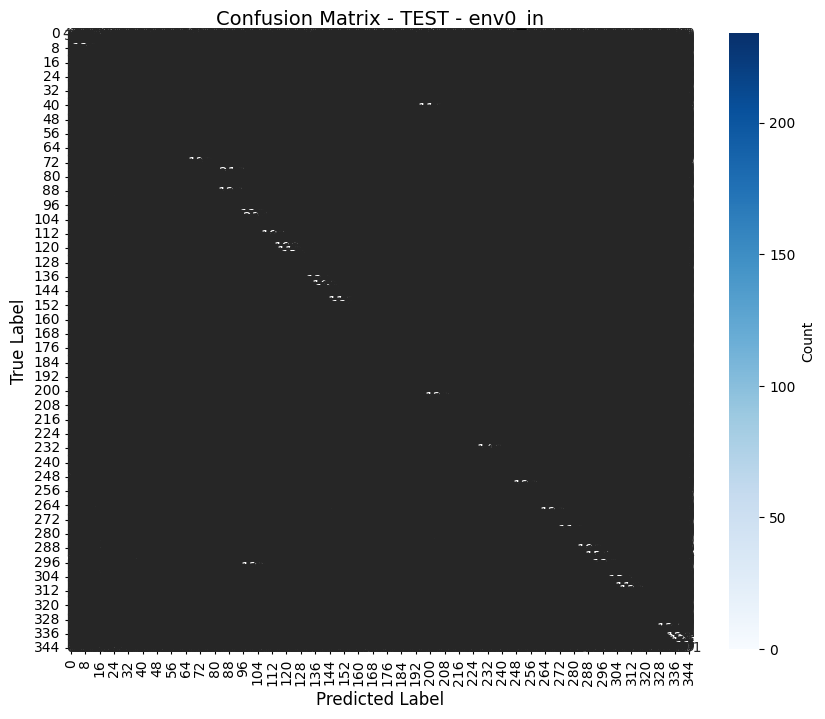


TRAIN - env1_in:
  Loss: 2.7525
  Accuracy: 0.1664, Precision: 0.2333, Recall: 0.1664, F1: 0.1789
  Saved CSV to: /kaggle/working/experiments/thried-experiment/logs/confusion_matrix_TRAIN_env1_in.csv
  Saved plot to: /kaggle/working/experiments/thried-experiment/logs/confusion_matrix_TRAIN_env1_in.png


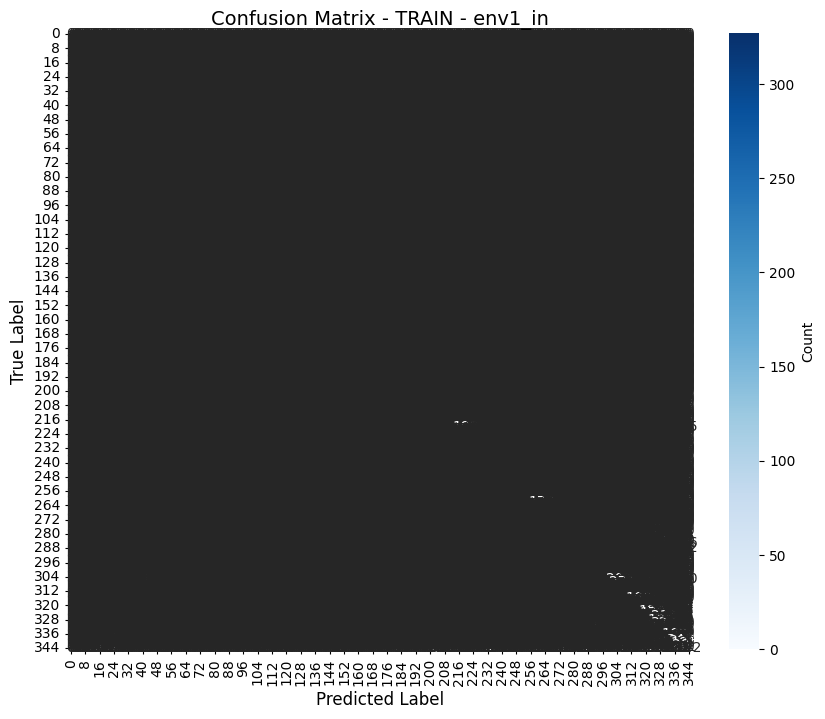


TRAIN - env2_in:
  Loss: 1.5194
  Accuracy: 0.2617, Precision: 0.3379, Recall: 0.2617, F1: 0.2770
  Saved CSV to: /kaggle/working/experiments/thried-experiment/logs/confusion_matrix_TRAIN_env2_in.csv
  Saved plot to: /kaggle/working/experiments/thried-experiment/logs/confusion_matrix_TRAIN_env2_in.png


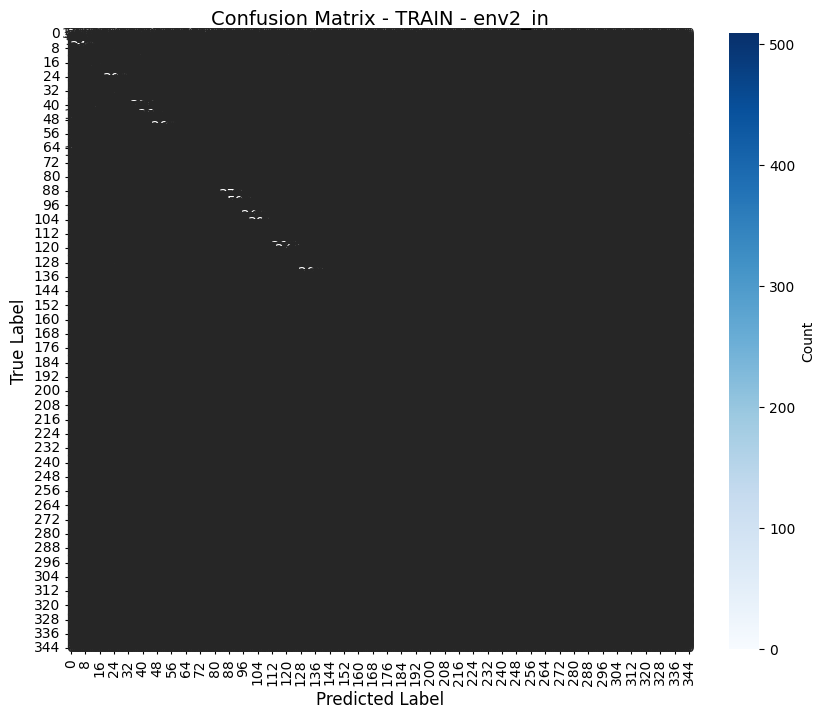


TRAIN - env3_in:
  Loss: 1.4590
  Accuracy: 0.5640, Precision: 0.5881, Recall: 0.5640, F1: 0.5595
  Saved CSV to: /kaggle/working/experiments/thried-experiment/logs/confusion_matrix_TRAIN_env3_in.csv
  Saved plot to: /kaggle/working/experiments/thried-experiment/logs/confusion_matrix_TRAIN_env3_in.png


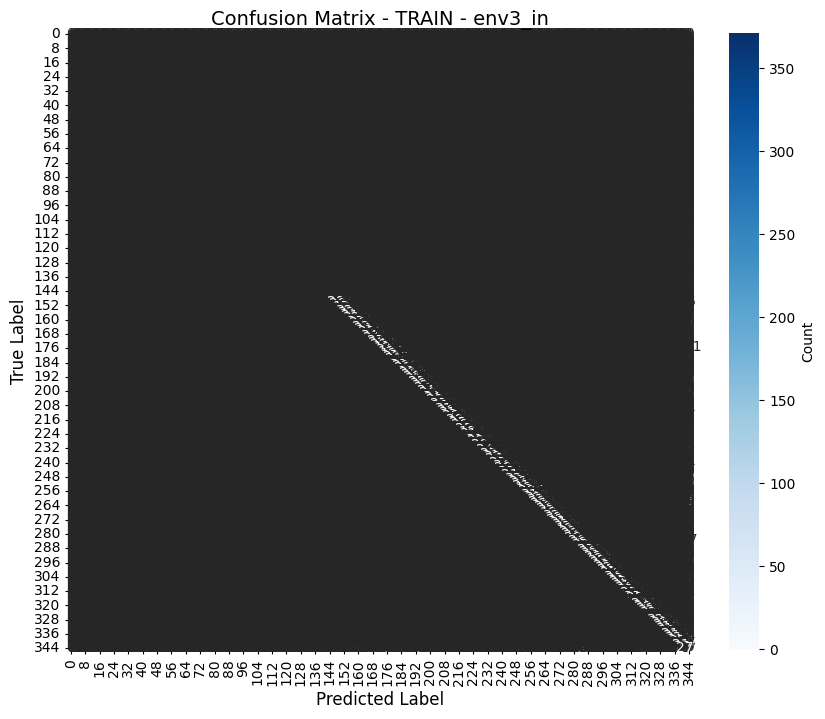


TRAIN - env4_in:
  Loss: 1.2794
  Accuracy: 0.3962, Precision: 0.4665, Recall: 0.3962, F1: 0.4179
  Saved CSV to: /kaggle/working/experiments/thried-experiment/logs/confusion_matrix_TRAIN_env4_in.csv
  Saved plot to: /kaggle/working/experiments/thried-experiment/logs/confusion_matrix_TRAIN_env4_in.png


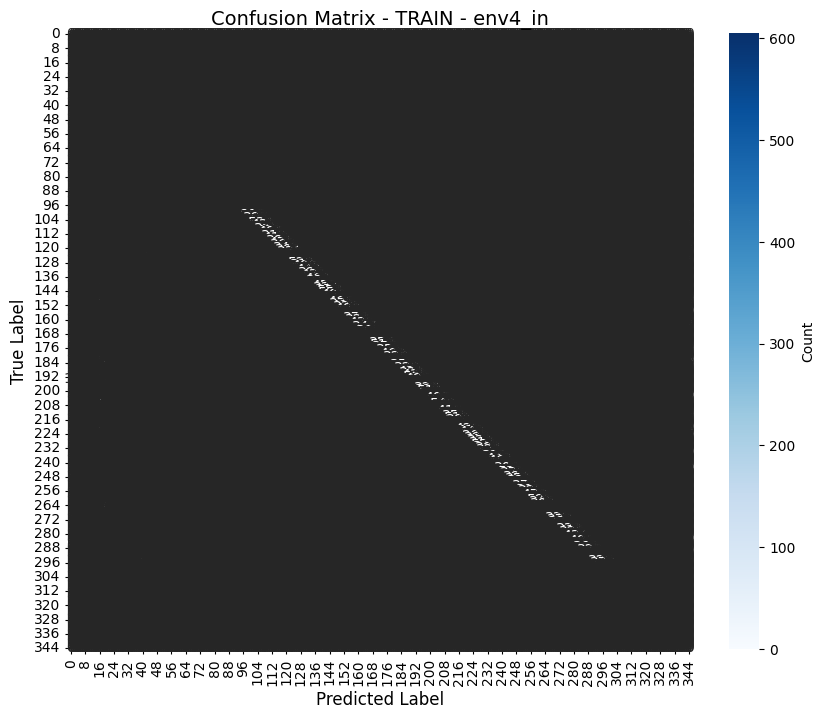


TRAIN - env5_in:
  Loss: 1.3149
  Accuracy: 0.4032, Precision: 0.4740, Recall: 0.4032, F1: 0.4227
  Saved CSV to: /kaggle/working/experiments/thried-experiment/logs/confusion_matrix_TRAIN_env5_in.csv
  Saved plot to: /kaggle/working/experiments/thried-experiment/logs/confusion_matrix_TRAIN_env5_in.png


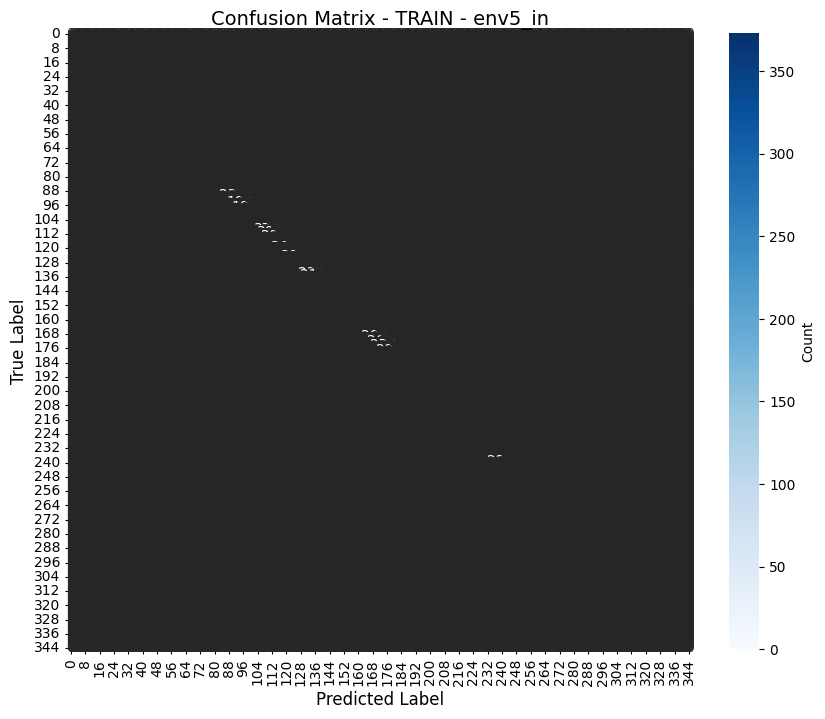


OTHER - env0_out:
  Loss: 2.7943
  Accuracy: 0.4370, Precision: 0.4974, Recall: 0.4370, F1: 0.4044
  Saved CSV to: /kaggle/working/experiments/thried-experiment/logs/confusion_matrix_OTHER_env0_out.csv
  Saved plot to: /kaggle/working/experiments/thried-experiment/logs/confusion_matrix_OTHER_env0_out.png


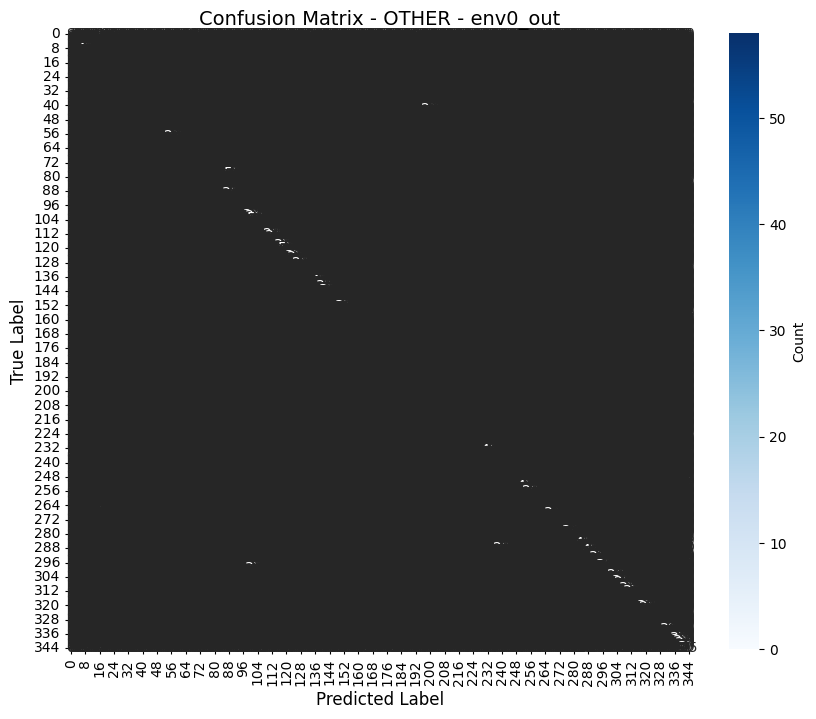


VAL - env1_out:
  Loss: 3.0869
  Accuracy: 0.1741, Precision: 0.2372, Recall: 0.1741, F1: 0.1846
  Saved CSV to: /kaggle/working/experiments/thried-experiment/logs/confusion_matrix_VAL_env1_out.csv
  Saved plot to: /kaggle/working/experiments/thried-experiment/logs/confusion_matrix_VAL_env1_out.png


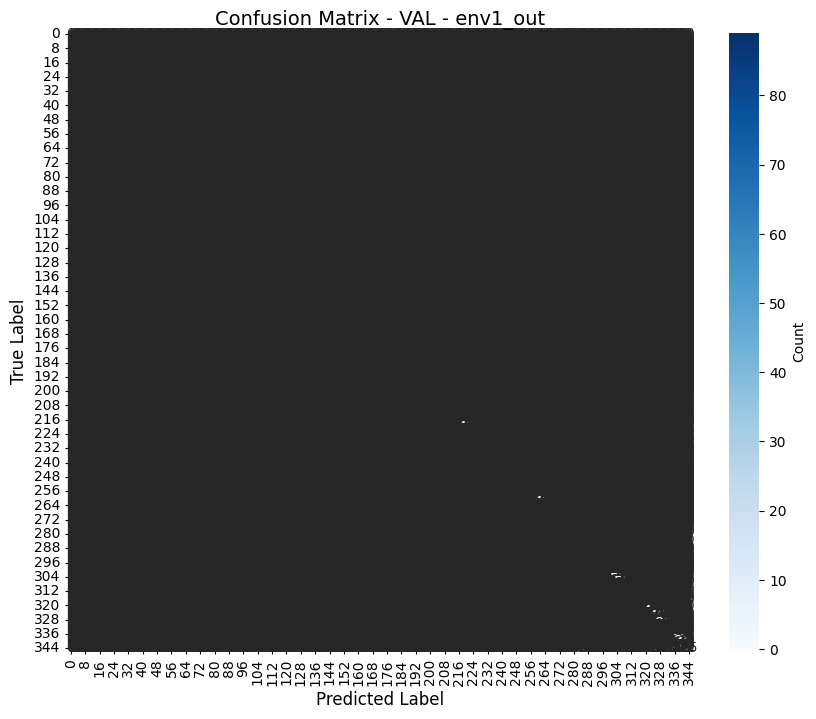


VAL - env2_out:
  Loss: 1.7523
  Accuracy: 0.2746, Precision: 0.3466, Recall: 0.2746, F1: 0.2871
  Saved CSV to: /kaggle/working/experiments/thried-experiment/logs/confusion_matrix_VAL_env2_out.csv
  Saved plot to: /kaggle/working/experiments/thried-experiment/logs/confusion_matrix_VAL_env2_out.png


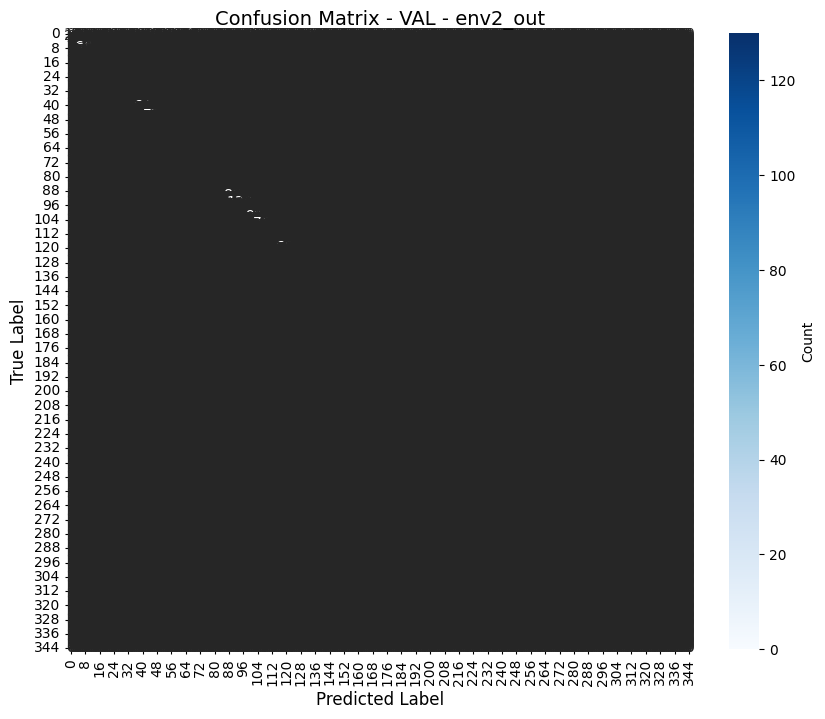


VAL - env3_out:
  Loss: 1.5355
  Accuracy: 0.5766, Precision: 0.6011, Recall: 0.5766, F1: 0.5703
  Saved CSV to: /kaggle/working/experiments/thried-experiment/logs/confusion_matrix_VAL_env3_out.csv
  Saved plot to: /kaggle/working/experiments/thried-experiment/logs/confusion_matrix_VAL_env3_out.png


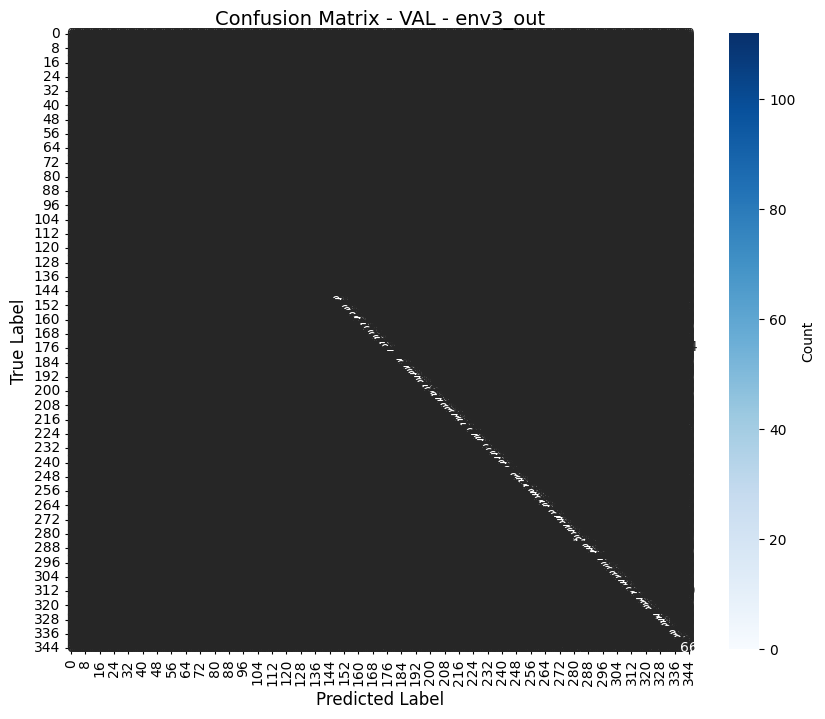


VAL - env4_out:
  Loss: 1.3399
  Accuracy: 0.4011, Precision: 0.4710, Recall: 0.4011, F1: 0.4221
  Saved CSV to: /kaggle/working/experiments/thried-experiment/logs/confusion_matrix_VAL_env4_out.csv
  Saved plot to: /kaggle/working/experiments/thried-experiment/logs/confusion_matrix_VAL_env4_out.png


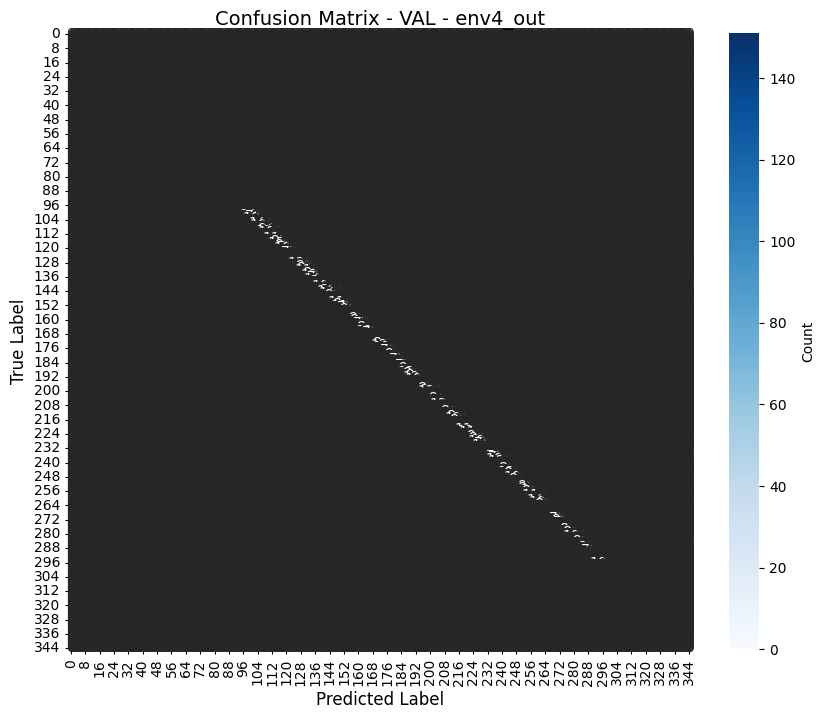


VAL - env5_out:
  Loss: 1.5953
  Accuracy: 0.3954, Precision: 0.4696, Recall: 0.3954, F1: 0.4121
  Saved CSV to: /kaggle/working/experiments/thried-experiment/logs/confusion_matrix_VAL_env5_out.csv
  Saved plot to: /kaggle/working/experiments/thried-experiment/logs/confusion_matrix_VAL_env5_out.png


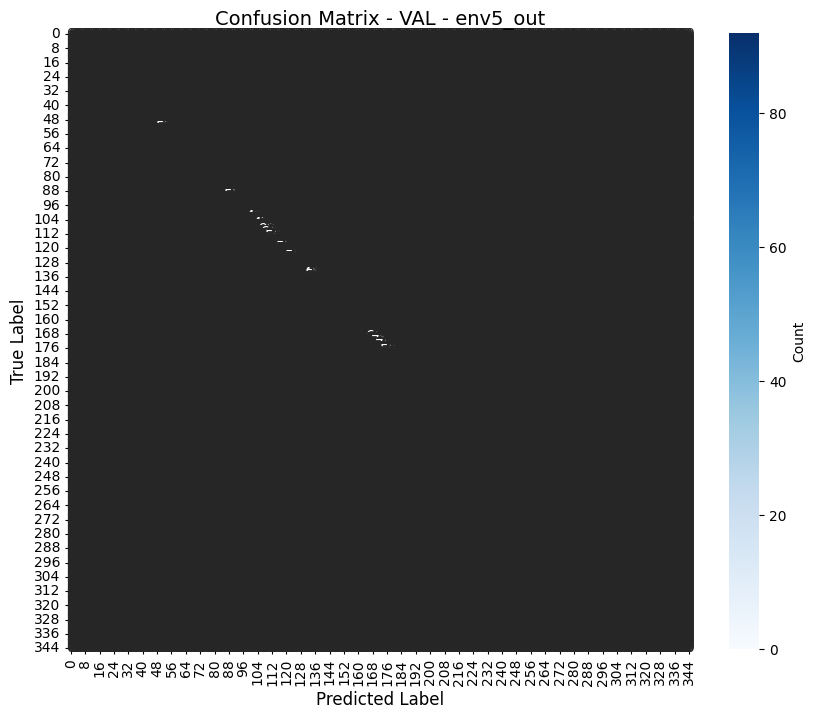


Training curves saved to: /kaggle/working/experiments/thried-experiment/logs/training_curves_DomainNet.png


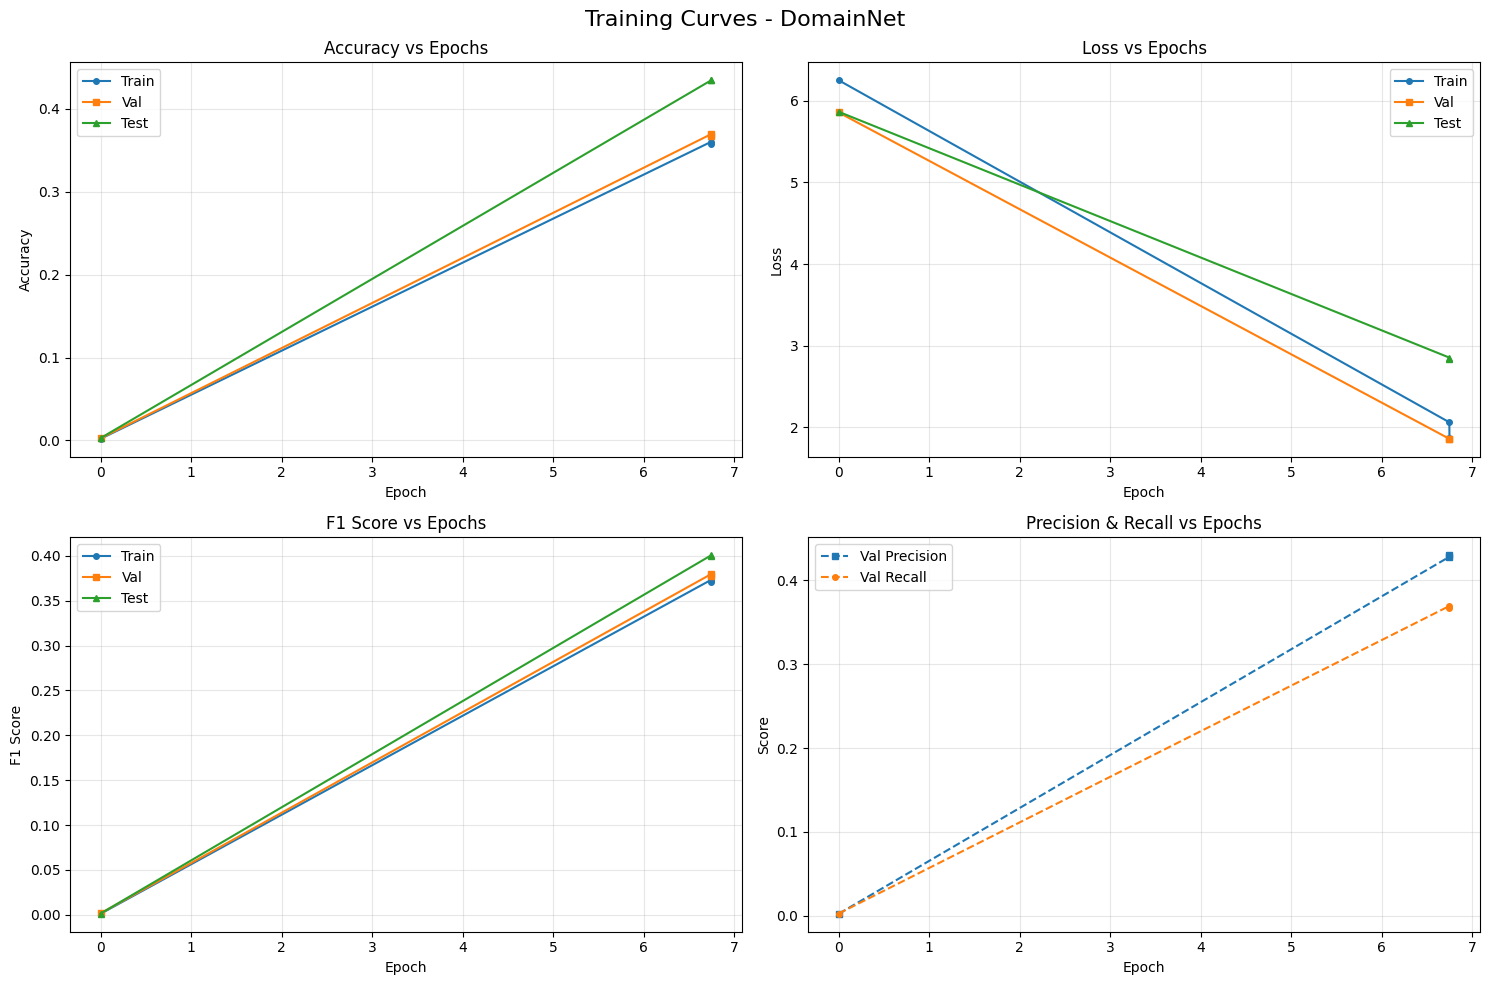

Epoch time plot saved to: /kaggle/working/experiments/thried-experiment/logs/epoch_times_DomainNet.png


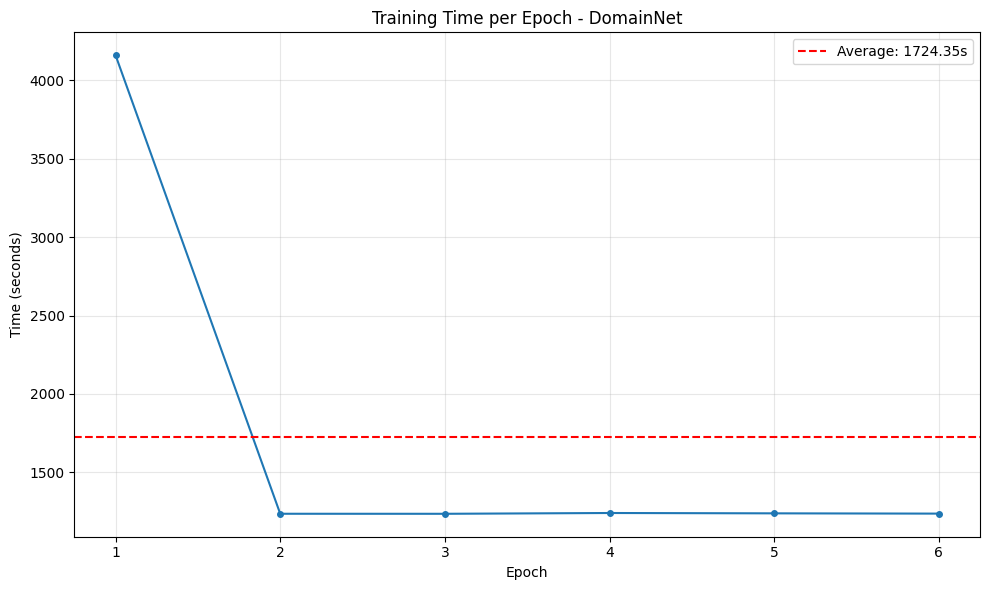


All results saved to: /kaggle/working/experiments/thried-experiment/logs

Summary of saved files:
  - model_statistics.json
  - training_time_statistics.json
  - epoch_history.json
  - training_curves_DomainNet.png
  - epoch_times_DomainNet.png
  - confusion_matrix_*.csv (for all splits)
  - confusion_matrix_*.png (heatmaps for all splits)


In [28]:
dataset_name = "DomainNet"
fit_simple(
    exp_dir=str(exp_dir),
    logger=logger,
    seed=config.get("seed", 0),
    trial_seed=config.get("trial_seed", 0),
    hparams_seed=config.get("hparams_seed", 0),
    algorithm_name=config["algo"],  
    dataset_name=dataset_name,
    data_dir=config["data_dir"][dataset_name],
    num_workers=config.get("num_workers", 4),
    test_envs=[config["test_set_id"]],
    overlap_type=config.get("overlap", "none"),
    holdout_fraction=config.get("holdout_fraction", 0.2),
    n_steps=config.get("n_epochs"),
    checkpoint_freq=config.get("checkpoint_freq"),
    model_checkpoint=config.get("model_checkpoint", {"metric": "val/acc", "maximize": True}),
    num_domain_linked_classes=config.get("num_domain_linked_classes"),
    num_classes=config.get("num_classes"),
    auto_augment=config.get("auto_augment", False),
    augment_search_epochs=config.get("augment_search_epochs", 10),
)
